In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Creating and Connecting Database

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
# Create Sales Table

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [4]:
# Inserting Sample Data

sales_data = [
    ("Laptop", 2, 50000),
    ("Mobile", 5, 15000),
    ("Headphones", 10, 2000),
    ("Laptop", 1, 52000),
    ("Mobile", 3, 14000),
    ("Headphones", 4, 1800)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)
conn.commit()

In [5]:
# Running SQL Query

query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)

In [6]:
# Displaying output

print("\n Sales Summary:\n")
print(df)


 Sales Summary:

      product  total_qty   revenue
0  Headphones         14   27200.0
1      Laptop          3  152000.0
2      Mobile          8  117000.0


<Figure size 640x480 with 0 Axes>

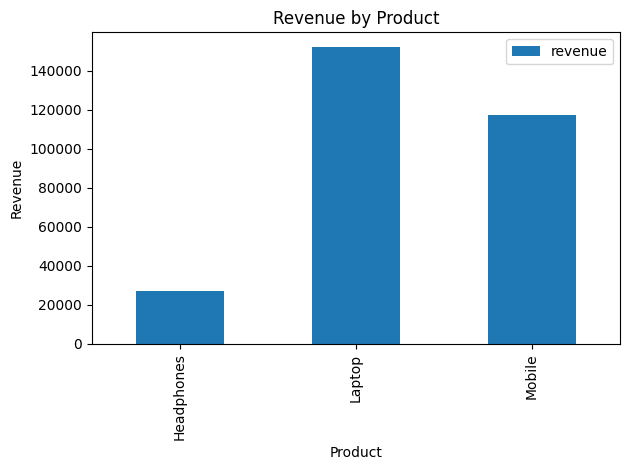

In [7]:
# Bar Chart Visualization

plt.figure()
df.plot(kind='bar', x='product', y='revenue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()

In [8]:
# Closing Connection

conn.close()